# Лабораторная работа №1

**Тема:** Построение морфологического скелета изображения и восстановление изображения по морфологическому скелету

**Студент:** Косило Павел Андреевич

## 1. Теоретическая справка

Морфологический скелет бинарного изображения $X$ структурирующим элементом $B$ вычисляется как объединение скелетных подмножеств $S_n(X)$:

$$
S_n(X) = (X \ominus nB) \setminus ((X \ominus nB) \circ B)
$$

$$
SK(X) = \bigcup_{n=0}^{N} S_n(X)
$$

Восстановление исходного изображения $X$ по его скелетным множествам выполняется по формуле:

$$
X = \bigcup_{n=0}^{N} [S_n(X) \oplus nB]
$$

Для оптимизации восстановления в коде используется итеративное расширение накопленного результата.

## 2. Исходные изображения

В работе используется программно сформированное бинарное тестовое изображение сложной формы, составленное из прямоугольников и кругов. Такой подход делает ноутбук самодостаточным и позволяет запускать его без загрузки внешних файлов.

Исходное бинарное изображение выводится в первой колонке итоговой визуализации, а обработка выполняется для двух различных структурирующих элементов:

1. **Крест** $3\times3$ для 4-связности.
2. **Квадрат** $3\times3$ для 8-связности.

Все вычисления выполняются для бинарного изображения со значениями пикселей `0` и `255`.

## 3. Код программы

Ниже приведён код, который:

1. Генерирует бинарное изображение.
2. Строит морфологический скелет для двух структурирующих элементов.
3. Восстанавливает исходное изображение по скелетным подмножествам.
4. Сравнивает восстановленное изображение с исходным и визуализирует результат.

Структурирующий элемент 'Крест' 3x3:
[[0 1 0]
 [1 1 1]
 [0 1 0]]

Структурирующий элемент 'Квадрат' 3x3:
[[1 1 1]
 [1 1 1]
 [1 1 1]]

Количество скелетных подмножеств для креста: 45
Количество скелетных подмножеств для квадрата: 41
Ошибки восстановления для креста: 0
Ошибки восстановления для квадрата: 0


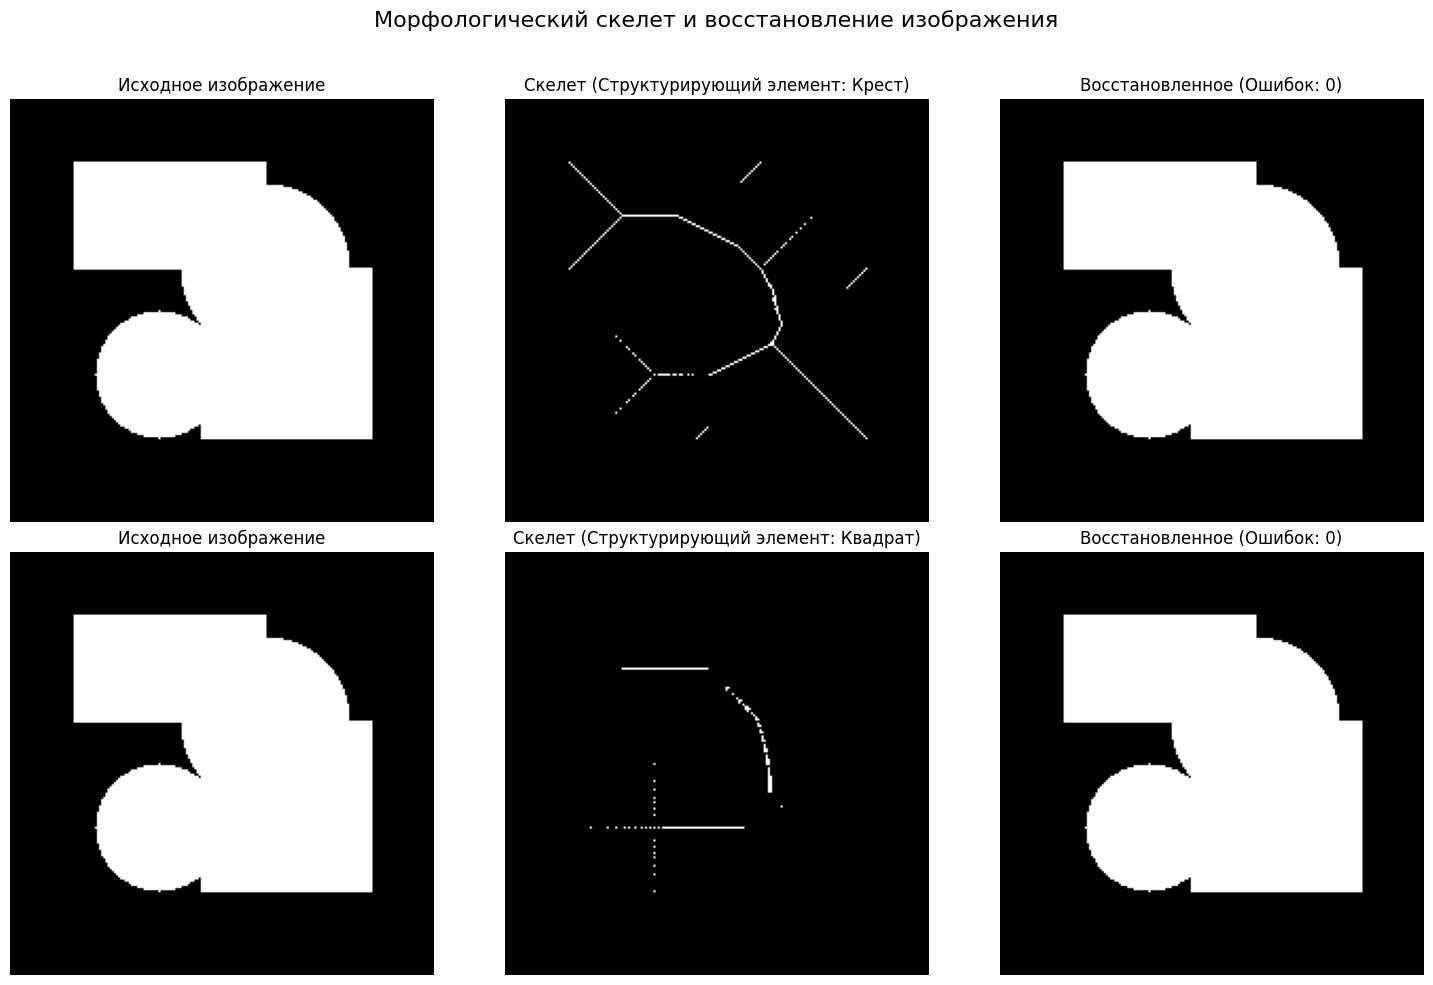

In [2]:
import importlib
import importlib.util
import subprocess
import sys

REQUIRED_PACKAGES = {
    "cv2": "opencv-python",
    "numpy": "numpy",
    "matplotlib": "matplotlib",
}

for module_name, package_name in REQUIRED_PACKAGES.items():
    if importlib.util.find_spec(module_name) is None:
        subprocess.check_call([sys.executable, "-m", "pip", "install", package_name])
        importlib.invalidate_caches()

cv2 = importlib.import_module("cv2")
np = importlib.import_module("numpy")
plt = importlib.import_module("matplotlib.pyplot")

def create_synthetic_image():
    """Создает тестовое бинарное изображение."""
    image = np.zeros((200, 200), dtype=np.uint8)
    cv2.rectangle(image, (30, 30), (120, 80), 255, -1)
    cv2.circle(image, (120, 80), 40, 255, -1)
    cv2.circle(image, (70, 130), 30, 255, -1)
    cv2.rectangle(image, (90, 80), (170, 160), 255, -1)
    return image

def morphological_skeleton(image, structuring_element):
    """
    Вычисляет морфологический скелет бинарного изображения.
    Возвращает итоговый скелет и список скелетных подмножеств Sn(X).
    """
    skeleton = np.zeros_like(image)
    eroded = image.copy()
    subsets = []

    while cv2.countNonZero(eroded) > 0:
        opened = cv2.morphologyEx(eroded, cv2.MORPH_OPEN, structuring_element)
        subset = cv2.subtract(eroded, opened)
        subsets.append(subset)
        skeleton = cv2.bitwise_or(skeleton, subset)
        eroded = cv2.erode(eroded, structuring_element)

    return skeleton, subsets

def reconstruct_from_skeleton(subsets, structuring_element):
    """
    Восстанавливает изображение по скелетным подмножествам Sn(X).
    Использует итеративное расширение накопленного результата.
    """
    if not subsets:
        raise ValueError("Список скелетных подмножеств пуст.")

    reconstructed = np.zeros_like(subsets[0])

    for index, subset in enumerate(reversed(subsets)):
        reconstructed = cv2.bitwise_or(reconstructed, subset)
        if index < len(subsets) - 1:
            reconstructed = cv2.dilate(reconstructed, structuring_element)

    return reconstructed

original_image = create_synthetic_image()

cross_element = cv2.getStructuringElement(cv2.MORPH_CROSS, (3, 3))
square_element = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))

skeleton_cross, subsets_cross = morphological_skeleton(original_image, cross_element)
skeleton_square, subsets_square = morphological_skeleton(original_image, square_element)

reconstructed_cross = reconstruct_from_skeleton(subsets_cross, cross_element)
reconstructed_square = reconstruct_from_skeleton(subsets_square, square_element)

diff_cross = cv2.absdiff(original_image, reconstructed_cross)
diff_square = cv2.absdiff(original_image, reconstructed_square)

cross_errors = int(cv2.countNonZero(diff_cross))
square_errors = int(cv2.countNonZero(diff_square))

print("Структурирующий элемент 'Крест' 3x3:")
print(cross_element)
print()
print("Структурирующий элемент 'Квадрат' 3x3:")
print(square_element)
print()
print(f"Количество скелетных подмножеств для креста: {len(subsets_cross)}")
print(f"Количество скелетных подмножеств для квадрата: {len(subsets_square)}")
print(f"Ошибки восстановления для креста: {cross_errors}")
print(f"Ошибки восстановления для квадрата: {square_errors}")

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle("Морфологический скелет и восстановление изображения", fontsize=16)

axes[0, 0].imshow(original_image, cmap="gray")
axes[0, 0].set_title("Исходное изображение")
axes[0, 0].axis("off")

axes[0, 1].imshow(skeleton_cross, cmap="gray")
axes[0, 1].set_title("Скелет (Структурирующий элемент: Крест)")
axes[0, 1].axis("off")

axes[0, 2].imshow(reconstructed_cross, cmap="gray")
axes[0, 2].set_title(f"Восстановленное (Ошибок: {cross_errors})")
axes[0, 2].axis("off")

axes[1, 0].imshow(original_image, cmap="gray")
axes[1, 0].set_title("Исходное изображение")
axes[1, 0].axis("off")

axes[1, 1].imshow(skeleton_square, cmap="gray")
axes[1, 1].set_title("Скелет (Структурирующий элемент: Квадрат)")
axes[1, 1].axis("off")

axes[1, 2].imshow(reconstructed_square, cmap="gray")
axes[1, 2].set_title(f"Восстановленное (Ошибок: {square_errors})")
axes[1, 2].axis("off")

plt.tight_layout(rect=(0, 0, 1, 0.96))
plt.show()

## 4. Результат работы программы

После выполнения кода формируется итоговая визуализация `2x3` и выводятся численные характеристики результата:

- Левая колонка: исходное бинарное изображение.
- Центральная колонка: морфологические скелеты для элементов Крест и Квадрат.
- Правая колонка: изображения, восстановленные по морфологическому скелету.
- Текстовый вывод: матрицы структурирующих элементов, количество скелетных подмножеств и число ошибок восстановления.

Для корректной реализации число ошибок восстановления должно быть равно `0`. В текущем варианте ноутбука для обоих структурирующих элементов выполняется точное восстановление исходного бинарного изображения.